In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2

In [ ]:
def plot_grid_search(cv_results, grid_param_1, grid_param_2, name_param_1, name_param_2, model=None, save_path=None, dpi=150):

    scores_mean = cv_results['mean_test_score']
    scores_mean = np.array(scores_mean).reshape(len(grid_param_2), len(grid_param_1))

    scores_sd = cv_results['std_test_score']
    scores_sd = np.array(scores_sd).reshape(len(grid_param_2), len(grid_param_1))

    _, ax = plt.subplots(1, 1)

    if model == 'svm':
        ax.set_xscale('log')

    for idx, val in enumerate(grid_param_2):
        ax.plot(grid_param_1, scores_mean[idx, :], '-o', label=name_param_2 + ': ' + str(val))

    ax.set_title('Grid Search Scores')
    ax.set_xlabel(name_param_1)
    ax.set_ylabel('CV Average Score')
    ax.legend(loc='best')
    ax.grid('on')

    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()

In [19]:
df = pd.read_csv('sdss_sample.csv')

In [20]:
features = ['u', 'g', 'r', 'i', 'z', 'redshift']
X = df[features]
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [21]:
scaler = MinMaxScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print('El accuracy del KNN en el conjunto de test es de ' + str(acc))


El accuracy del KNN en el conjunto de test es de 0.9966666666666667


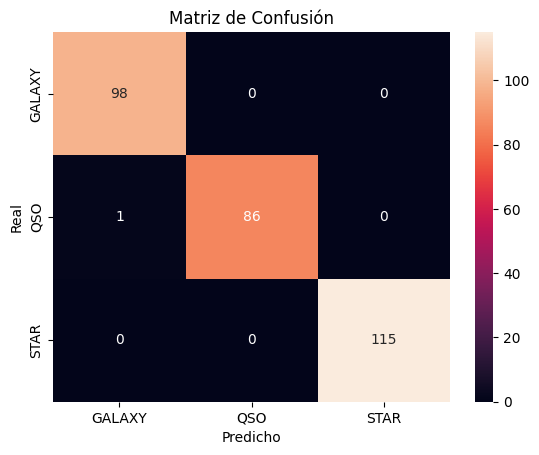

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['GALAXY','QSO','STAR'],
            yticklabels=['GALAXY','QSO','STAR'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
Path('outputs').mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

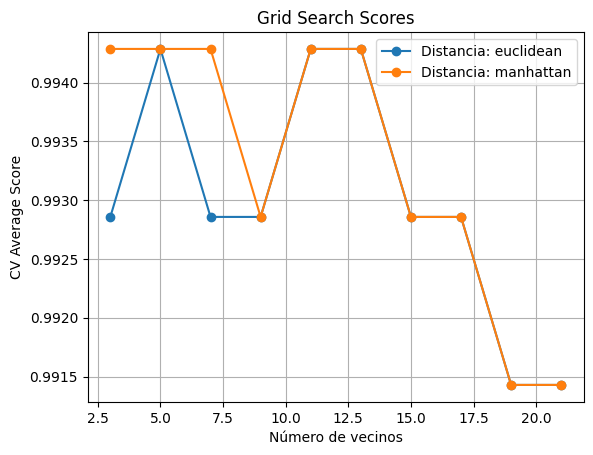

In [ ]:
KNN = KNeighborsClassifier()
parameters = {'n_neighbors': (3, 5, 7, 9, 11, 13, 15, 17, 19, 21),
              'metric': ('euclidean', 'manhattan')}

clf = GridSearchCV(KNN,
                   parameters,
                   scoring='accuracy',
                   cv=5,
                   return_train_score=True)
clf.fit(X_train, y_train)

plot_grid_search(clf.cv_results_, [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
                 ['euclidean', 'manhattan'],
                 'Número de vecinos', 'Distancia',
                 save_path='outputs/knn_gridsearch_base.png', dpi=150)

In [25]:
y_pred = clf.predict(X_test)
print('El accuracy del KNN en el conjunto de test es de ' + str(accuracy_score(y_test, y_pred)))
print('Los mejores parametros fueron: ')
print(clf.best_params_)

El accuracy del KNN en el conjunto de test es de 0.9966666666666667
Los mejores parametros fueron: 
{'metric': 'euclidean', 'n_neighbors': 5}


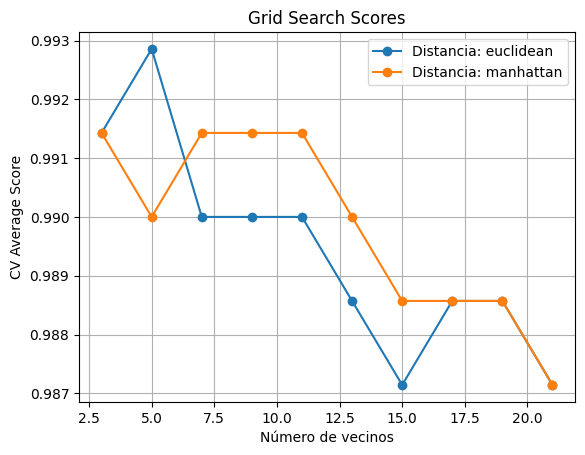

In [ ]:
selector = SelectKBest(chi2, k=5)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

KNN = KNeighborsClassifier()
parameters = {'n_neighbors': (3, 5, 7, 9, 11, 13, 15, 17, 19, 21),
              'metric': ('euclidean', 'manhattan')}

clf = GridSearchCV(KNN,
                   parameters,
                   scoring='accuracy',
                   cv=5,
                   return_train_score=True)
clf.fit(X_train, y_train)
plot_grid_search(clf.cv_results_, [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
                 ['euclidean', 'manhattan'],
                 'Número de vecinos', 'Distancia',
                 save_path='outputs/knn_gridsearch_kbest.png', dpi=150)